[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/hospitalization-risk-predictor/blob/main/notebooks/02_model_training.ipynb)

# Entrenamiento y Selección de Modelo — Predicción de Riesgo de Hospitalización

Este notebook parte de las decisiones ya documentadas en `01_eda.ipynb`: variable objetivo (`hospitalizado_12m`), predictores candidatos, y el desbalance de clases confirmado (82.71%/17.29%).

**Objetivo:** comparar sistemáticamente distintas combinaciones de (estrategia de balanceo × algoritmo), seleccionar el mejor candidato con evidencia, y serializarlo para despliegue en `app/model/`.

In [1]:
import pandas as pd
import numpy as np

filename = "dataset_ofuscado_colombia_diabetes_hipertension.csv"
df = pd.read_csv(filename)

# Exclusiones ya justificadas en 01_eda.ipynb (sección 5.3): identificadores,
# constantes, redundantes o con fuga de datos confirmada
columnas_excluir_predictores = [
    'id_registro', 'fecha_corte', 'hospitalizacion_relacionada_12m',
    'evento_cardiovascular_12m', 'muerte_12m', 'riesgo_alto_12m', 'categoria_imc',
]

df['hospitalizado_12m'] = (df['hospitalizaciones_12m'] > 0).astype(int)

predictores_candidatos = [
    col for col in df.columns
    if col not in columnas_excluir_predictores + ['hospitalizaciones_12m', 'hospitalizado_12m']
]

X = df[predictores_candidatos].copy()
y = df['hospitalizado_12m'].copy()

variables_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object", "str"]).columns.tolist()

print(f"Predictores: {X.shape[1]} ({len(variables_numericas)} numéricas, {len(variables_categoricas)} categóricas)")
print(f"Filas: {X.shape[0]} | Proporción positiva: {y.mean():.4f}")

Predictores: 49 (33 numéricas, 16 categóricas)
Filas: 1500000 | Proporción positiva: 0.1729


## 1. Partición Train/Test

Se reserva 20% para prueba, estratificado por la proporción de clases. `X_test`/`y_test` quedan intocables hasta la evaluación final (Sección 6) — nunca se usan para elegir ni ajustar nada.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} ({y_train.mean():.4f} positivos)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4f} positivos)")

Train: (1200000, 49) (0.1729 positivos)
Test:  (300000, 49) (0.1729 positivos)


## 2. Preprocesamiento

Sin `SimpleImputer` — el EDA confirmó 0 valores faltantes en todo el dataset.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), variables_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), variables_categoricas)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 3. Muestra de Screening

Con 1.5M de filas, el screening masivo de combinaciones se corre sobre una muestra estratificada más manejable, no sobre el train completo.

In [4]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=150_000, stratify=y_train, random_state=42
)
print(f"Muestra de screening: {X_sample.shape}, {y_sample.mean():.4f} positivos")

Muestra de screening: (150000, 49), 0.1729 positivos


## 4. Screening: Estrategias de Balanceo × Algoritmos

Se comparan 5 estrategias de balanceo contra 5 algoritmos, evaluados con validación cruzada (5 folds) y `average_precision` (AUC-PR) — más informativo que AUC-ROC ante desbalance de clases.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

def construir_modelos(usar_class_weight):
    cw = 'balanced' if usar_class_weight else None
    return {
        "LogisticRegression": LogisticRegression(class_weight=cw, max_iter=1000, solver='lbfgs'),
        "RandomForest": RandomForestClassifier(class_weight=cw, n_estimators=150, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(class_weight=cw, random_state=42, n_jobs=-1, verbose=-1),
    }

configuraciones = [
    ("sin_balanceo",            False, None),
    ("class_weight_balanced",   True,  None),
    ("undersampling_1_1",       False, RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("undersampling_0.5",       False, RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ("class_weight+undersamp",  True,  RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
]

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nombre_config, usar_cw, undersampler in configuraciones:
    modelos = construir_modelos(usar_cw)

    for nombre_modelo, modelo in modelos.items():
        if usar_cw and nombre_modelo == "GradientBoosting":
            continue  # no soporta class_weight nativo

        if undersampler is None:
            pipe = Pipeline([("preprocess", preprocessor), ("clf", modelo)])
        else:
            pipe = ImbPipeline([
                ("preprocess", preprocessor),
                ("undersample", undersampler),
                ("clf", modelo)
            ])

        scores = cross_validate(
            pipe, X_sample, y_sample, cv=skf,
            scoring=["roc_auc", "average_precision", "recall", "precision", "f1"],
            n_jobs=-1, error_score='raise'
        )

        resultados.append({
            "configuracion": nombre_config,
            "modelo": nombre_modelo,
            "auc_roc": scores["test_roc_auc"].mean(),
            "auc_pr": scores["test_average_precision"].mean(),
            "auc_pr_std": scores["test_average_precision"].std(),
            "recall": scores["test_recall"].mean(),
            "precision": scores["test_precision"].mean(),
            "f1": scores["test_f1"].mean(),
        })
        print(f"✓ {nombre_config} + {nombre_modelo} — AUC-PR: {resultados[-1]['auc_pr']:.4f}")

resultados_df = pd.DataFrame(resultados).sort_values("auc_pr", ascending=False)

✓ sin_balanceo + LogisticRegression — AUC-PR: 0.2850
✓ sin_balanceo + RandomForest — AUC-PR: 0.2629
✓ sin_balanceo + GradientBoosting — AUC-PR: 0.2842
✓ sin_balanceo + XGBoost — AUC-PR: 0.2592
✓ sin_balanceo + LightGBM — AUC-PR: 0.2802
✓ class_weight_balanced + LogisticRegression — AUC-PR: 0.2849
✓ class_weight_balanced + RandomForest — AUC-PR: 0.2693
✓ class_weight_balanced + XGBoost — AUC-PR: 0.2592
✓ class_weight_balanced + LightGBM — AUC-PR: 0.2816
✓ undersampling_1_1 + LogisticRegression — AUC-PR: 0.2847
✓ undersampling_1_1 + RandomForest — AUC-PR: 0.2652
✓ undersampling_1_1 + GradientBoosting — AUC-PR: 0.2832
✓ undersampling_1_1 + XGBoost — AUC-PR: 0.2551
✓ undersampling_1_1 + LightGBM — AUC-PR: 0.2779
✓ undersampling_0.5 + LogisticRegression — AUC-PR: 0.2848
✓ undersampling_0.5 + RandomForest — AUC-PR: 0.2677
✓ undersampling_0.5 + GradientBoosting — AUC-PR: 0.2833
✓ undersampling_0.5 + XGBoost — AUC-PR: 0.2584
✓ undersampling_0.5 + LightGBM — AUC-PR: 0.2777
✓ class_weight+unders

In [7]:
print(resultados_df.to_string(index=False))

         configuracion             modelo  auc_roc   auc_pr  auc_pr_std   recall  precision       f1
          sin_balanceo LogisticRegression 0.668385 0.284972    0.004707 0.003085   0.532020 0.006132
 class_weight_balanced LogisticRegression 0.668450 0.284858    0.004826 0.595334   0.263229 0.365040
     undersampling_0.5 LogisticRegression 0.668334 0.284802    0.004663 0.247195   0.318821 0.278440
     undersampling_1_1 LogisticRegression 0.668369 0.284678    0.004573 0.601928   0.262319 0.365395
class_weight+undersamp LogisticRegression 0.668369 0.284678    0.004573 0.601928   0.262319 0.365395
          sin_balanceo   GradientBoosting 0.668121 0.284200    0.005440 0.001774   0.475868 0.003529
     undersampling_0.5   GradientBoosting 0.667343 0.283264    0.005312 0.183073   0.334032 0.236270
     undersampling_1_1   GradientBoosting 0.667531 0.283150    0.004853 0.675381   0.249569 0.364417
 class_weight_balanced           LightGBM 0.665015 0.281551    0.004394 0.640910   0.253618

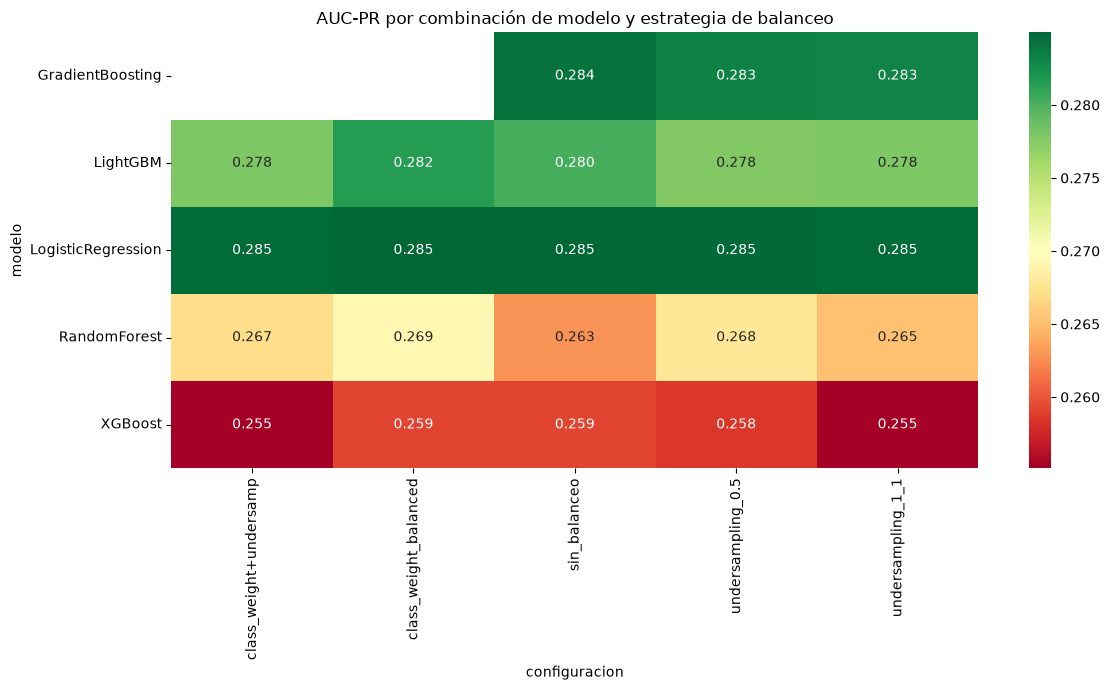

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
pivot = resultados_df.pivot(index="modelo", columns="configuracion", values="auc_pr")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn")
plt.title("AUC-PR por combinación de modelo y estrategia de balanceo")
plt.tight_layout()
plt.show()

## 5. Afinamiento de Hiperparámetros — Top 3 Candidatos

Se toman las 3 mejores combinaciones del screening y se afinan con `RandomizedSearchCV` sobre el conjunto de entrenamiento completo (1.2M filas).

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    "LogisticRegression": {
        "clf__C": np.logspace(-3, 2, 20),
        "clf__l1_ratio": [0, 0.3, 0.5, 0.7, 1.0],
        #"clf__penalty": ["elasticnet"],
        "clf__solver": ["saga"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7, 10],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__scale_pos_weight": [1, (y_train==0).sum()/(y_train==1).sum()],
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__num_leaves": [15, 31, 63],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
}

In [12]:
top_3 = resultados_df.head(3)
print(top_3[["configuracion", "modelo", "auc_pr"]])

mejores_modelos_afinados = {}

for _, fila in top_3.iterrows():
    nombre_config, nombre_modelo = fila["configuracion"], fila["modelo"]
    print(f"\nAfinando: {nombre_config} + {nombre_modelo}")

    cw = 'balanced' if 'class_weight' in nombre_config else None
    modelo_base = construir_modelos(cw is not None)[nombre_modelo]

    if "undersampling" in nombre_config:
        proporcion = 1.0 if "1_1" in nombre_config else 0.5
        pipe = ImbPipeline([
            ("preprocess", preprocessor),
            ("undersample", RandomUnderSampler(sampling_strategy=proporcion, random_state=42)),
            ("clf", modelo_base)
        ])
    else:
        pipe = Pipeline([("preprocess", preprocessor), ("clf", modelo_base)])

    search = RandomizedSearchCV(
        pipe, param_distributions=param_grids[nombre_modelo],
        n_iter=25, cv=3, scoring="average_precision", n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)

    mejores_modelos_afinados[f"{nombre_config}_{nombre_modelo}"] = search
    print(f"Mejor AUC-PR (CV): {search.best_score_:.4f}")
    print(f"Mejores parámetros: {search.best_params_}")

            configuracion              modelo    auc_pr
0            sin_balanceo  LogisticRegression  0.284972
5   class_weight_balanced  LogisticRegression  0.284858
14      undersampling_0.5  LogisticRegression  0.284802

Afinando: sin_balanceo + LogisticRegression


KeyboardInterrupt: 

## 6. Evaluación Final sobre Test

Comparación de los 3 finalistas afinados, sobre el conjunto de prueba nunca antes usado, con la métrica alineada al KPI de negocio de la Pregunta SMART (precisión ≥80% en el 10-20% de pacientes priorizados).

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

resultados_finales = []

for nombre, search in mejores_modelos_afinados.items():
    modelo = search.best_estimator_
    y_proba = modelo.predict_proba(X_test)[:, 1]

    top_k = int(len(y_test) * 0.15)
    idx_top = np.argsort(y_proba)[::-1][:top_k]
    precision_top_k = y_test.iloc[idx_top].mean()

    resultados_finales.append({
        "candidato": nombre,
        "auc_roc_test": roc_auc_score(y_test, y_proba),
        "auc_pr_test": average_precision_score(y_test, y_proba),
        "precision_top15pct": precision_top_k,
    })

resultados_finales_df = pd.DataFrame(resultados_finales).sort_values("precision_top15pct", ascending=False)
print(resultados_finales_df.to_string(index=False))

## 7. Modelo Final Seleccionado

In [ ]:
mejor_candidato_nombre = resultados_finales_df.iloc[0]["candidato"]
mejor_modelo_final = mejores_modelos_afinados[mejor_candidato_nombre].best_estimator_

print(f"MODELO SELECCIONADO: {mejor_candidato_nombre}\n")
print(classification_report(y_test, mejor_modelo_final.predict(X_test)))
print(confusion_matrix(y_test, mejor_modelo_final.predict(X_test)))

## 8. Serialización para Despliegue

Se guarda el `Pipeline` completo (preprocesamiento + modelo) — en producción solo se carga este archivo y se llama `.predict_proba()` sobre datos crudos.

In [ ]:
import joblib
import os

os.makedirs("../app/model", exist_ok=True)
joblib.dump(mejor_modelo_final, "../app/model/modelo_riesgo_hospitalizacion_v1.pkl")

resultados_df.to_csv("screening_completo.csv", index=False)
resultados_finales_df.to_csv("comparacion_finalistas.csv", index=False)

print("Modelo guardado en app/model/modelo_riesgo_hospitalizacion_v1.pkl")